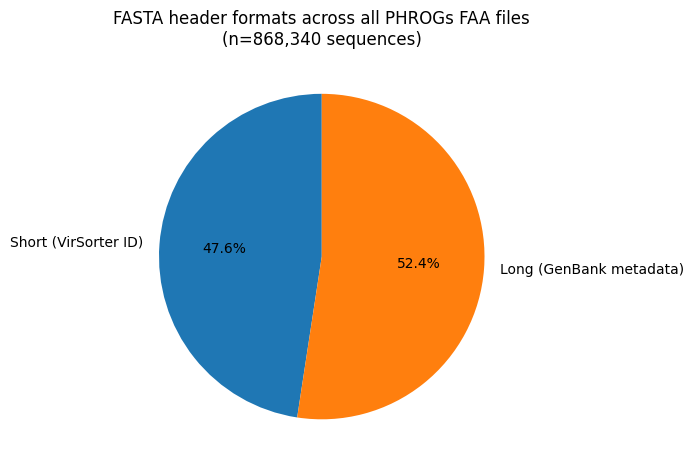

Short: 413,203  |  Long: 455,137  |  Total: 868,340


In [1]:
import tarfile
import matplotlib.pyplot as plt

short_count = 0
long_count = 0

with tarfile.open("data/FAA_phrog.tar.gz") as t:
    for member in t.getmembers():
        if not member.name.endswith(".faa"):
            continue
        f = t.extractfile(member)
        for line in f:
            if line.startswith(b">"):
                if b"!!" in line:
                    long_count += 1
                else:
                    short_count += 1

labels = ["Short (VirSorter ID)", "Long (GenBank metadata)"]
sizes  = [short_count, long_count]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
ax.set_title(f"FASTA header formats across all PHROGs FAA files\n(n={short_count + long_count:,} sequences)")
plt.tight_layout()
plt.show()

print(f"Short: {short_count:,}  |  Long: {long_count:,}  |  Total: {short_count + long_count:,}")


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import tarfile

mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "axes.linewidth":     0.75,
    "xtick.major.width":  0.75,
    "ytick.major.width":  0.75,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         300,
})


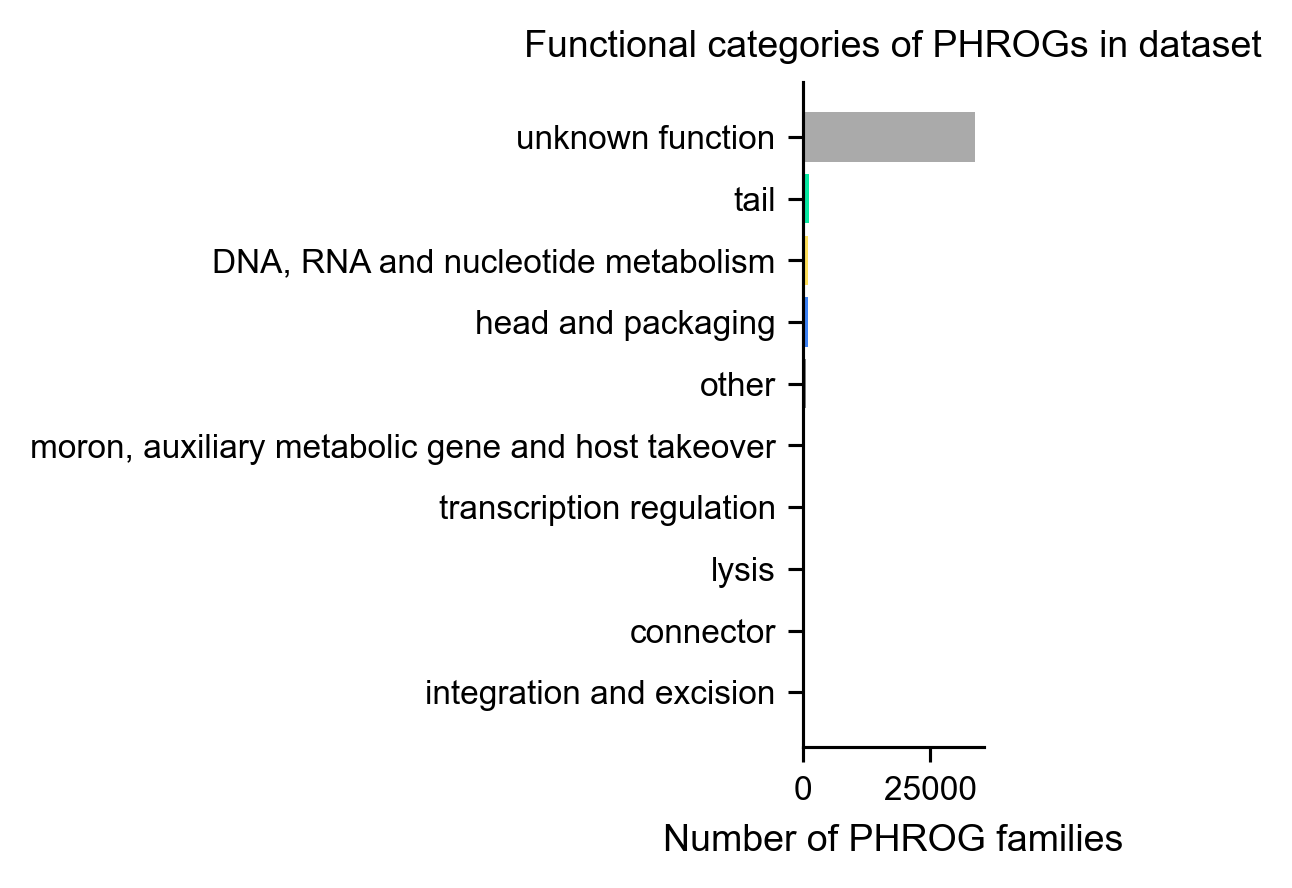

In [3]:
# Get PHROG IDs present in the FAA archive
phrog_ids = set()
with tarfile.open("data/FAA_phrog.tar.gz") as t:
    for member in t.getmembers():
        if member.name.endswith(".faa"):
            name = member.name.split("/")[-1]          # phrog_10.faa
            pid = int(name.replace("phrog_", "").replace(".faa", ""))
            phrog_ids.add(pid)

annot = pd.read_csv("data/phrog_annot_v4.tsv", sep="\t")
annot_map = annot.set_index("phrog")["category"].to_dict()

categories = [annot_map.get(pid, "unknown function") for pid in phrog_ids]
cat_counts = pd.Series(categories).value_counts().sort_values()

# category colours from PHROGs (one representative colour per category)
cat_color = (
    annot.dropna(subset=["category", "color"])
    .groupby("category")["color"]
    .first()
    .to_dict()
)
cat_color["unknown function"] = "#aaaaaa"
colors = [cat_color.get(c, "#aaaaaa") for c in cat_counts.index]

fig, ax = plt.subplots(figsize=(3.54, 3.0))
ax.barh(cat_counts.index, cat_counts.values, color=colors, linewidth=0)
ax.set_xlabel("Number of PHROG families")
ax.set_title("Functional categories of PHROGs in dataset")
ax.tick_params(axis="y", pad=3)
plt.tight_layout()
plt.show()


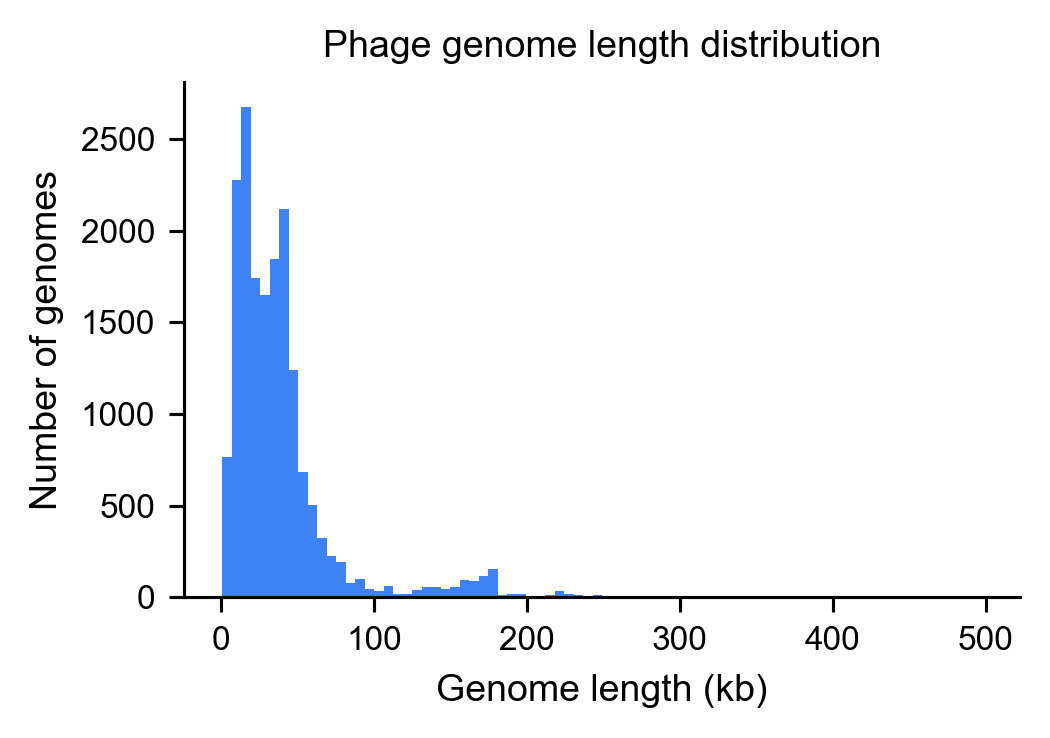

In [4]:
db = pd.read_csv("data/newPhageDB_and_VirSorter.tsv", sep="\t")

fig, ax = plt.subplots(figsize=(3.54, 2.5))
ax.hist(db["Length"].dropna() / 1000, bins=80, color="#3e83f6", linewidth=0)
ax.set_xlabel("Genome length (kb)")
ax.set_ylabel("Number of genomes")
ax.set_title("Phage genome length distribution")
plt.tight_layout()
plt.show()


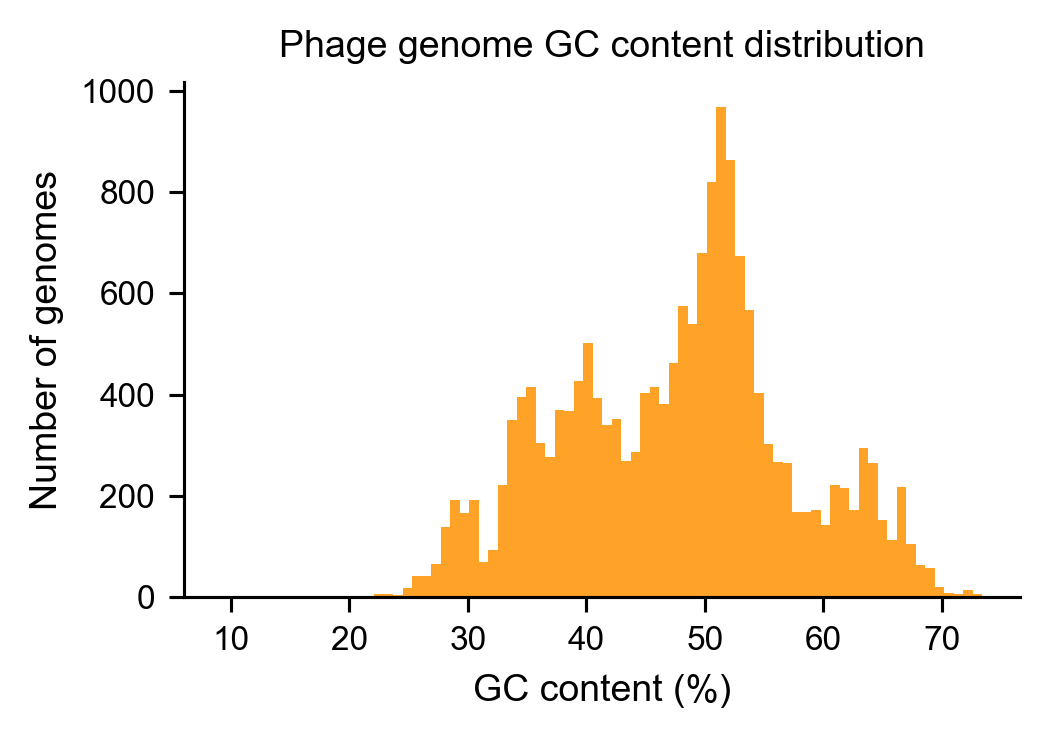

In [5]:
fig, ax = plt.subplots(figsize=(3.54, 2.5))
ax.hist(db["GC"].dropna(), bins=80, color="#fea328", linewidth=0)
ax.set_xlabel("GC content (%)")
ax.set_ylabel("Number of genomes")
ax.set_title("Phage genome GC content distribution")
plt.tight_layout()
plt.show()


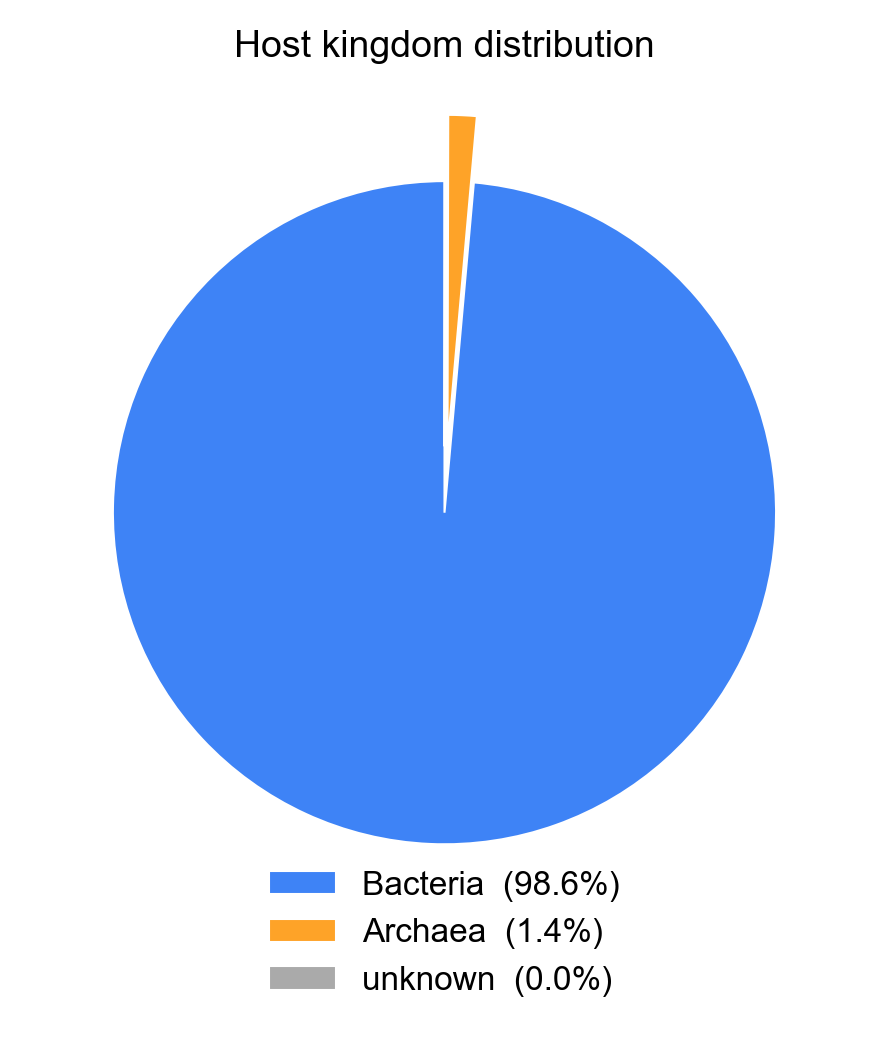

In [12]:
db = pd.read_csv("data/newPhageDB_and_VirSorter.tsv", sep="\t")

kingdom_counts = db["Superkingdom"].value_counts()
total = kingdom_counts.sum()
colors = [{"Bacteria": "#3e83f6", "Archaea": "#fea328", "unknown": "#aaaaaa"}[k] for k in kingdom_counts.index]
explode = [0.0 if v / total > 0.05 else 0.2 for v in kingdom_counts.values]

legend_labels = [f"{k}  ({v/total*100:.1f}%)" for k, v in zip(kingdom_counts.index, kingdom_counts.values)]

fig, ax = plt.subplots(figsize=(3.5, 3.5))
wedges, _ = ax.pie(
    kingdom_counts.values,
    labels=None,
    autopct=None,
    colors=colors,
    startangle=90,
    explode=explode,
    wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
)
ax.legend(
    wedges, legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=1,
    fontsize=8,
    frameon=False,
)
ax.set_title("Host kingdom distribution", pad=10)
plt.tight_layout()
plt.show()


In [4]:
import tarfile

zero_len_count = 0
total_count = 0

with tarfile.open("data/FAA_phrog.tar.gz") as t:
    for member in t.getmembers():
        if not member.name.endswith(".faa"):
            continue
        f = t.extractfile(member)
        content = f.read().decode("utf-8")
        for block in content.split(">")[1:]:
            lines = block.strip().split("\n")
            seq = "".join(lines[1:])
            total_count += 1
            if len(seq) == 0:
                zero_len_count += 1

print(f"Total sequences:     {total_count:,}")
print(f"Zero-length:         {zero_len_count:,}")
print(f"Would be kept:       {total_count - zero_len_count:,}")
print(f"Dropped (%):         {zero_len_count / total_count * 100:.3f}%")


Total sequences:     868,397
Zero-length:         57
Would be kept:       868,340
Dropped (%):         0.007%


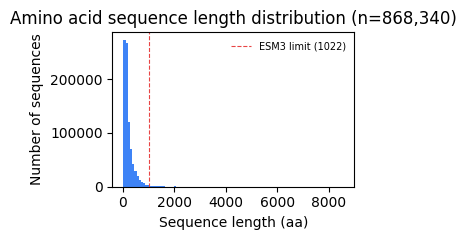

Min: 17 aa
Median: 145 aa
Mean:   222.7 aa
>1022:  11,402 (1.3%)


In [8]:
import tarfile
import matplotlib.pyplot as plt
import numpy as np

seq_lengths = []

with tarfile.open("data/FAA_phrog.tar.gz") as t:
    for member in t.getmembers():
        if not member.name.endswith(".faa"):
            continue
        f = t.extractfile(member)
        content = f.read().decode("utf-8")
        for block in content.split(">")[1:]:
            lines = block.strip().split("\n")
            seq = "".join(lines[1:])
            if len(seq) > 0:
                seq_lengths.append(len(seq))

seq_lengths = np.array(seq_lengths)

fig, ax = plt.subplots(figsize=(3.54, 2.5))
ax.hist(seq_lengths, bins=100, color="#3e83f6", linewidth=0)
ax.set_xlabel("Sequence length (aa)")
ax.set_ylabel("Number of sequences")
ax.set_title(f"Amino acid sequence length distribution (n={len(seq_lengths):,})")
ax.axvline(1022, color="#e84545", linewidth=0.8, linestyle="--", label="ESM3 limit (1022)")
ax.legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

print(f"Min: {int(np.min(seq_lengths))} aa")

print(f"Median: {int(np.median(seq_lengths))} aa")
print(f"Mean:   {seq_lengths.mean():.1f} aa")
print(f">1022:  {(seq_lengths > 1022).sum():,} ({(seq_lengths > 1022).mean()*100:.1f}%)")
